In [3]:
import pandas as pd
import numpy as np

In [4]:
df_cleaned = pd.read_csv("../data/processed/country_vaccinations_clean.csv")

### Dataset Overview
We examine the structure and summary statistics of the cleaned dataset to understand distributions and ranges of key variables.

In [5]:
df_cleaned.head()
df_cleaned.describe()

,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million
count,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04,8.651200e+04,86512.000000,86512.000000,86512.000000,86512.000000
mean,2.589502e+07,1.330478e+07,1.000081e+07,1.106083e+05,1.308517e+05,67.115687,34.874463,27.606726,3245.792248
std,1.614748e+08,7.771445e+07,6.588661e+07,7.864756e+05,7.669487e+05,65.232437,29.544334,28.203818,3932.156455
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.179840e+05,7.373500e+04,2.254600e+04,0.000000e+00,8.770000e+02,6.930000,4.970000,1.380000,629.000000
50%,1.079840e+06,6.806300e+05,3.440630e+05,0.000000e+00,7.245000e+03,47.360000,29.690000,16.770000,2036.000000
75%,8.265793e+06,4.441924e+06,3.146539e+06,1.280625e+04,4.370450e+04,118.362500,62.750000,53.130000,4667.000000
max,3.263129e+09,1.275541e+09,1.240777e+09,2.474100e+07,2.242429e+07,345.370000,124.760000,122.370000,117497.000000


### Global Vaccination Trend
This plot shows how total vaccinations have increased over time globally.

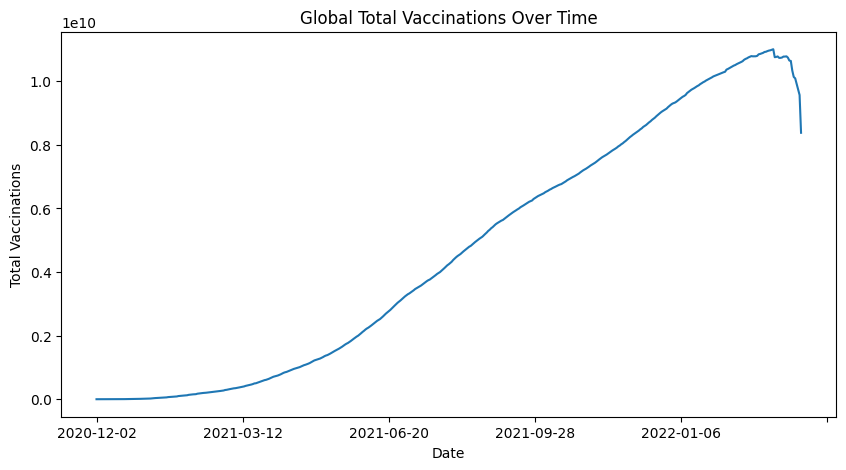

In [6]:
import matplotlib.pyplot as plt

# Example: global trend (sum per day)
global_trend = df_cleaned.groupby('date')['total_vaccinations'].sum()

plt.figure(figsize=(10,5))
global_trend.plot()
plt.title("Global Total Vaccinations Over Time")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.show()

### Top Countries
We identify the countries with the highest total vaccinations.

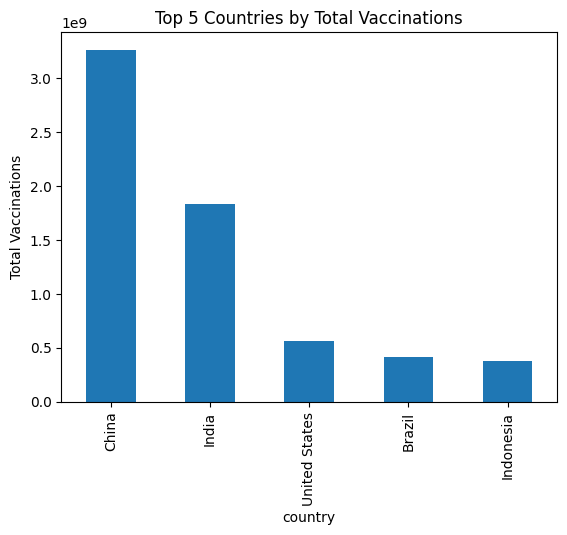

In [7]:
# Top 5 countries by total vaccinations
top_countries = df_cleaned.groupby('country')['total_vaccinations'].max().sort_values(ascending=False).head(5)

top_countries.plot(kind='bar')
plt.title("Top 5 Countries by Total Vaccinations")
plt.ylabel("Total Vaccinations")
plt.show()

### Daily Vaccinations Trend
This shows how daily vaccination efforts fluctuate over time.

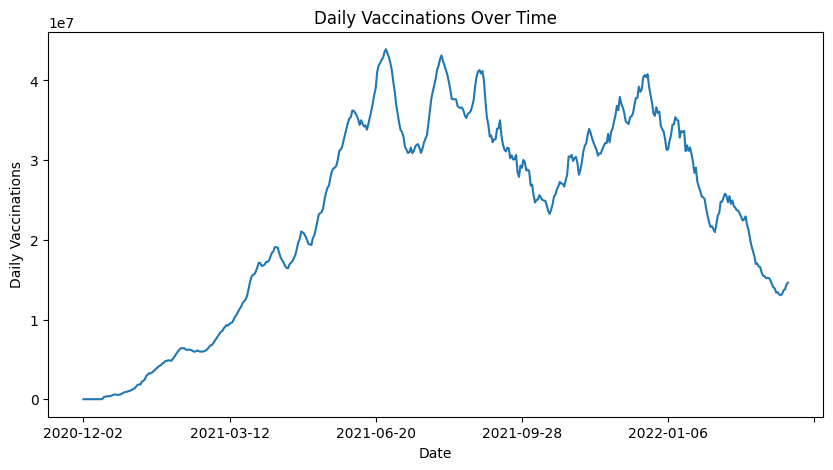

In [8]:
daily_trend = df_cleaned.groupby('date')['daily_vaccinations'].sum()

plt.figure(figsize=(10,5))
daily_trend.plot()
plt.title("Daily Vaccinations Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Vaccinations")
plt.show()

### Vaccine Usage
This shows the most commonly used vaccine combinations across countries.

In [9]:
# Count frequency of vaccine combinations
df_cleaned['vaccines'].value_counts().head(10)

vaccines
Johnson&Johnson,Moderna,Oxford/AstraZeneca,Pfizer/BioNTech            7608
Moderna,Oxford/AstraZeneca,Pfizer/BioNTech                            6263
Oxford/AstraZeneca                                                    6022
Oxford/AstraZeneca,Pfizer/BioNTech                                    4629
Johnson&Johnson,Moderna,Novavax,Oxford/AstraZeneca,Pfizer/BioNTech    3564
Johnson&Johnson,Oxford/AstraZeneca,Sinopharm/Beijing                  2484
Moderna,Pfizer/BioNTech                                               2309
Pfizer/BioNTech                                                       2271
Oxford/AstraZeneca,Pfizer/BioNTech,Sinopharm/Beijing,Sputnik V        2041
Oxford/AstraZeneca,Pfizer/BioNTech,Sinopharm/Beijing                  2030
Name: count, dtype: int64

### Correlation Analysis
We examine relationships between numerical variables such as total and daily vaccinations.

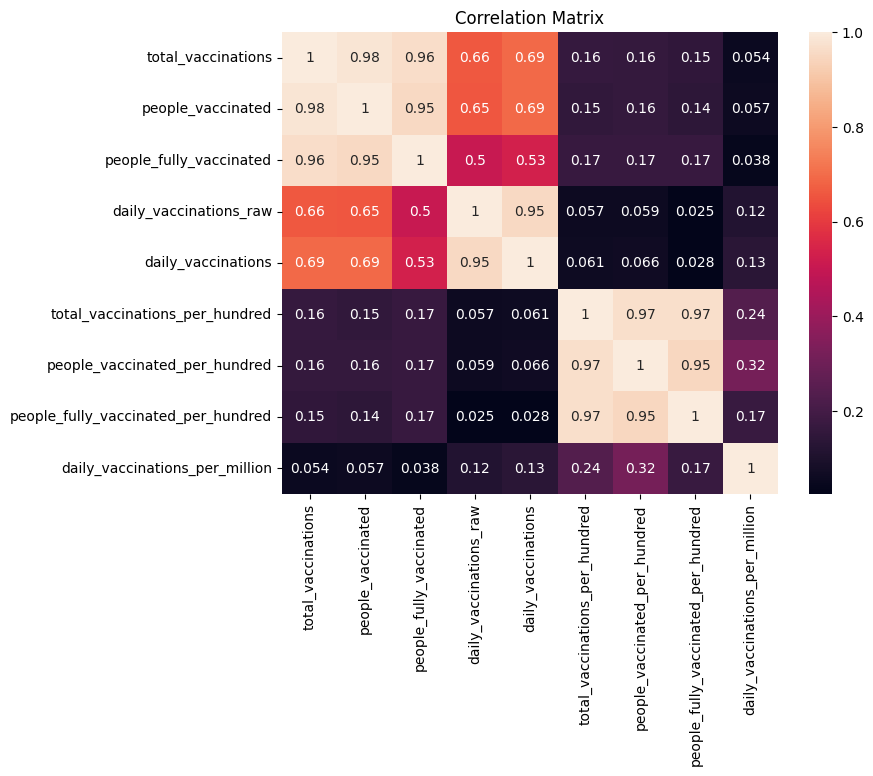

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Key Insights

- Global vaccinations show a steady increase over time.
- A few countries China, India, USA, Brazil and Indonesia dominate total vaccination counts.
- Daily vaccinations fluctuate, possibly due to reporting delays or supply changes.
- Vaccine distribution varies across countries.

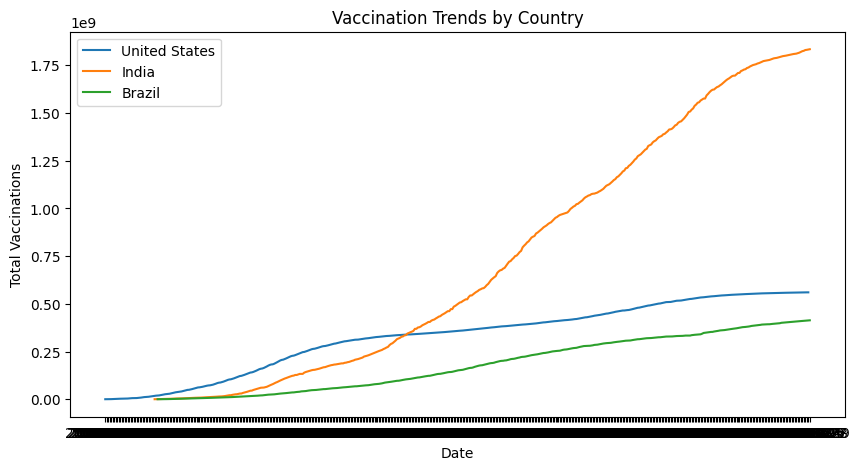

In [11]:
countries = ['United States', 'India', 'Brazil']

plt.figure(figsize=(10,5))

for country in countries:
    data = df_cleaned[df_cleaned['country'] == country]
    plt.plot(data['date'], data['total_vaccinations'], label=country)

plt.legend()
plt.title("Vaccination Trends by Country")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.show()